In [1]:
import zipfile
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq

In [2]:
import raw_data_processing
import data_pre_processing
import simclr_utitlities
import transformations

# %%
working_directory = 'test_run/'
dataset_save_path = working_directory
if not os.path.exists(working_directory):
    os.mkdir(working_directory)

In [3]:
with zipfile.ZipFile(working_directory + 'B_Accelerometer_data.zip', 'r') as zip_ref:
    zip_ref.extractall(working_directory)

accelerometer_data_folder_path = working_directory + 'B_Accelerometer_data/'
user_datasets = raw_data_processing.process_motion_sense_accelerometer_files(accelerometer_data_folder_path)

with open(working_directory + 'motion_sense_user_split.pkl', 'wb') as f:
    pickle.dump({
        'user_split': user_datasets,
    }, f)

window_size = 400
input_shape = (window_size, 3)

transformation_multiple = 1
dataset_name = 'motion_sense.pkl'
dataset_name_user_split = 'motion_sense_user_split.pkl'

label_list = ['null', 'sit', 'std', 'wlk', 'ups', 'dws', 'jog'] # label_list = ['null', 'sit', 'std', 'wlk', 'ups', 'dws', 'jog']
label_list_full_name = ['null', 'sitting', 'standing', 'walking', 'walking upstairs', 'walking downstairs', 'jogging'] # label_list_full_name = ['null', 'sitting', 'standing', 'walking', 'walking upstairs', 'walking downstairs', 'jogging']
has_null_class = True

label_map = dict([(l, i) for i, l in enumerate(label_list)])

output_shape = len(label_list)

model_save_name = f"motionsense_acc"

sampling_rate = 50.0

test_users_fixed = [1, 14, 19, 23, 6]
def get_fixed_split_users(har_users):
    # test_users = har_users[0::5]
    test_users = test_users_fixed
    train_users = [u for u in har_users if u not in test_users]
    return (train_users, test_users)

with open(dataset_save_path + dataset_name_user_split, 'rb') as f:
    dataset_dict = pickle.load(f)
    user_datasets = dataset_dict['user_split']

har_users = list(user_datasets.keys())
train_users, test_users = get_fixed_split_users(har_users)
print(f'Testing: {test_users}, Training: {train_users}')

np_train, np_val, np_test = data_pre_processing.pre_process_dataset_composite(
    user_datasets=user_datasets, 
    label_map=label_map, 
    output_shape=output_shape, 
    train_users=train_users, 
    test_users=test_users, 
    window_size=window_size, 
    shift=window_size//2, 
    normalise_dataset=True, 
    verbose=1
)

test_run/B_Accelerometer_data\dws_1
test_run/B_Accelerometer_data\dws_11
test_run/B_Accelerometer_data\dws_2
test_run/B_Accelerometer_data\jog_16
test_run/B_Accelerometer_data\jog_9
test_run/B_Accelerometer_data\sit_13
test_run/B_Accelerometer_data\sit_5
test_run/B_Accelerometer_data\std_14
test_run/B_Accelerometer_data\std_6
test_run/B_Accelerometer_data\ups_12
test_run/B_Accelerometer_data\ups_3
test_run/B_Accelerometer_data\ups_4
test_run/B_Accelerometer_data\wlk_15
test_run/B_Accelerometer_data\wlk_7
test_run/B_Accelerometer_data\wlk_8
Testing: [1, 14, 19, 23, 6], Training: [10, 11, 12, 13, 15, 16, 17, 18, 2, 20, 21, 22, 24, 3, 4, 5, 7, 8, 9]
Test
(array(['dws', 'jog', 'sit', 'std', 'ups', 'wlk'], dtype='<U3'), array([112, 133, 360, 335, 148, 331], dtype=int64))
(array([1, 2, 3, 4, 5, 6]), array([360, 335, 331, 148, 112, 133], dtype=int64))
-----------------
Train
(array(['dws', 'jog', 'sit', 'std', 'ups', 'wlk'], dtype='<U3'), array([ 449,  480, 1282, 1146,  546, 1308], dtype=int6

In [ ]:
def plot_raw_vs_transformed(np_train, n_samples=3, transform='rotation', label_names=None):
    """
    Plot raw vs transformed accelerometer signals side by side.
    
    Args:
        np_train:     tuple of (X, y) where X has shape (N, window_size, 3)
        n_samples:    number of example windows to plot
        transform:    transformation to apply
        label_names:  list mapping class index -> full label name.
                      Defaults to label_list_full_name if None.
    """
    if callable(transform):
        transform_fn   = transform
        transform_name = transform.__name__
    else:
        raise TypeError(f"`transform` must be a string or callable, got {type(transform)}.")

    if label_names is None:
        label_names = label_list_full_name

    X, y = np_train[0], np_train[1]
    sample_windows      = X[:n_samples]
    transformed_windows = transform_fn(sample_windows)

    axes_labels = ['X', 'Y', 'Z']
    axes_colors = ['tab:blue', 'tab:orange', 'tab:green']

    fig, axes = plt.subplots(n_samples, 2, figsize=(14, 4 * n_samples))
    fig.suptitle(f'Raw vs {transform_name} Accelerometer Signal',
                 fontsize=14, fontweight='bold')

    for i in range(n_samples):
        raw         = sample_windows[i]
        transformed = transformed_windows[i]

        ax_raw  = axes[i, 0]
        ax_tran = axes[i, 1]

        for j, (label, color) in enumerate(zip(axes_labels, axes_colors)):
            ax_raw.plot(raw[:, j],          label=label, color=color, linewidth=0.9)
            ax_tran.plot(transformed[:, j], label=label, color=color, linewidth=0.9)

        class_idx  = y[i].argmax()
        class_name = label_names[class_idx] if class_idx < len(label_names) else class_idx

        ax_raw.set_title(f'Sample {i+1} — Raw (label: {class_name})')
        ax_tran.set_title(f'Sample {i+1} — {transform_name}')

        for ax in (ax_raw, ax_tran):
            ax.set_xlabel('Time step')
            ax.set_ylabel('Acceleration (g)')
            #ax.legend(loc='upper right')
            ax.grid(False, alpha=0.3)

    plt.tight_layout()
    plt.show()

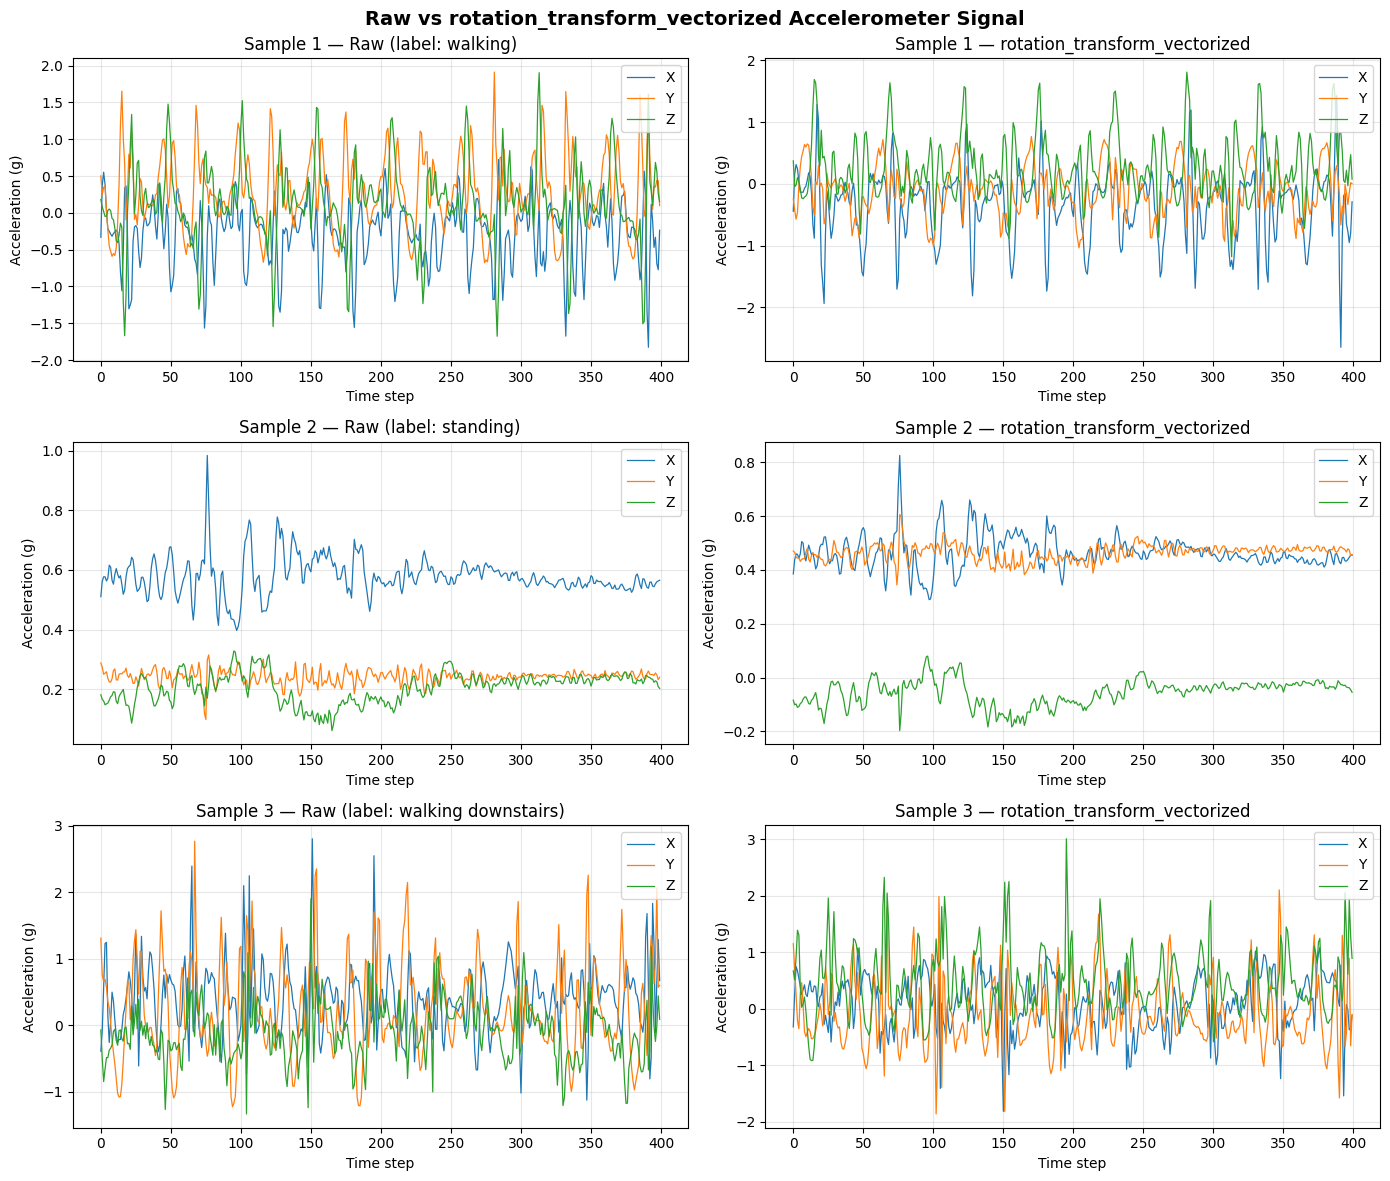

In [11]:
plot_raw_vs_transformed(np_train, n_samples=3, transform=transformations.rotation_transform_vectorized)

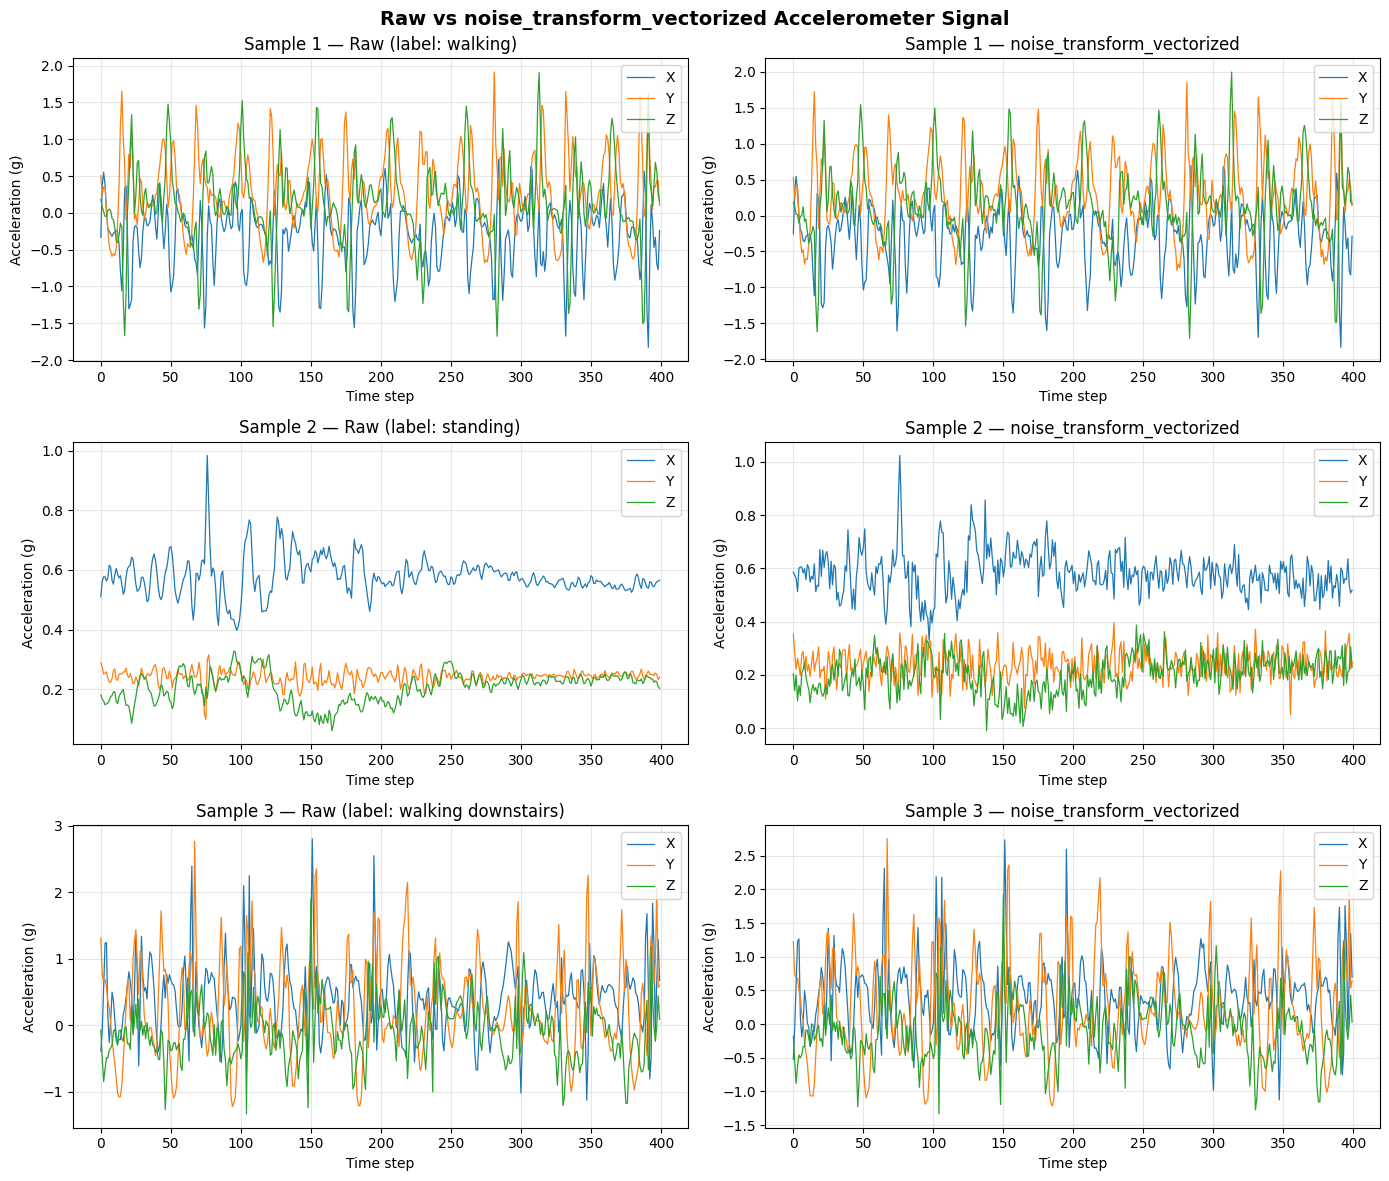

In [12]:
plot_raw_vs_transformed(np_train, n_samples=3, transform=transformations.noise_transform_vectorized)

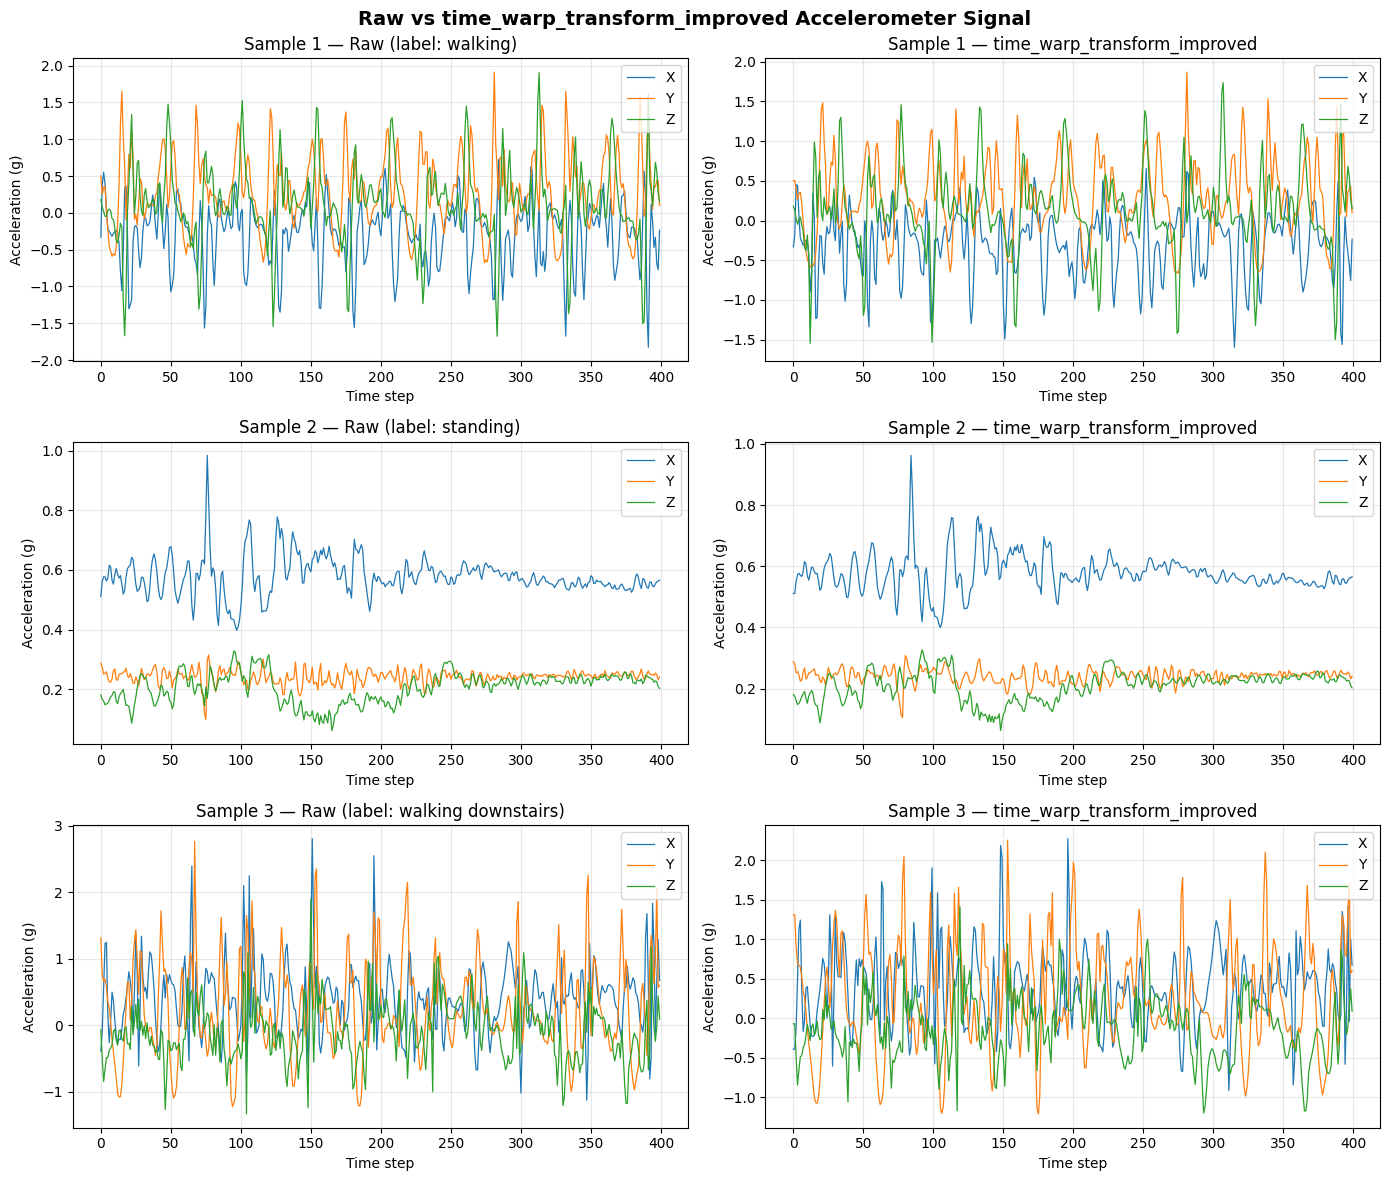

In [14]:
plot_raw_vs_transformed(np_train, n_samples=3, transform=transformations.time_warp_transform_improved)

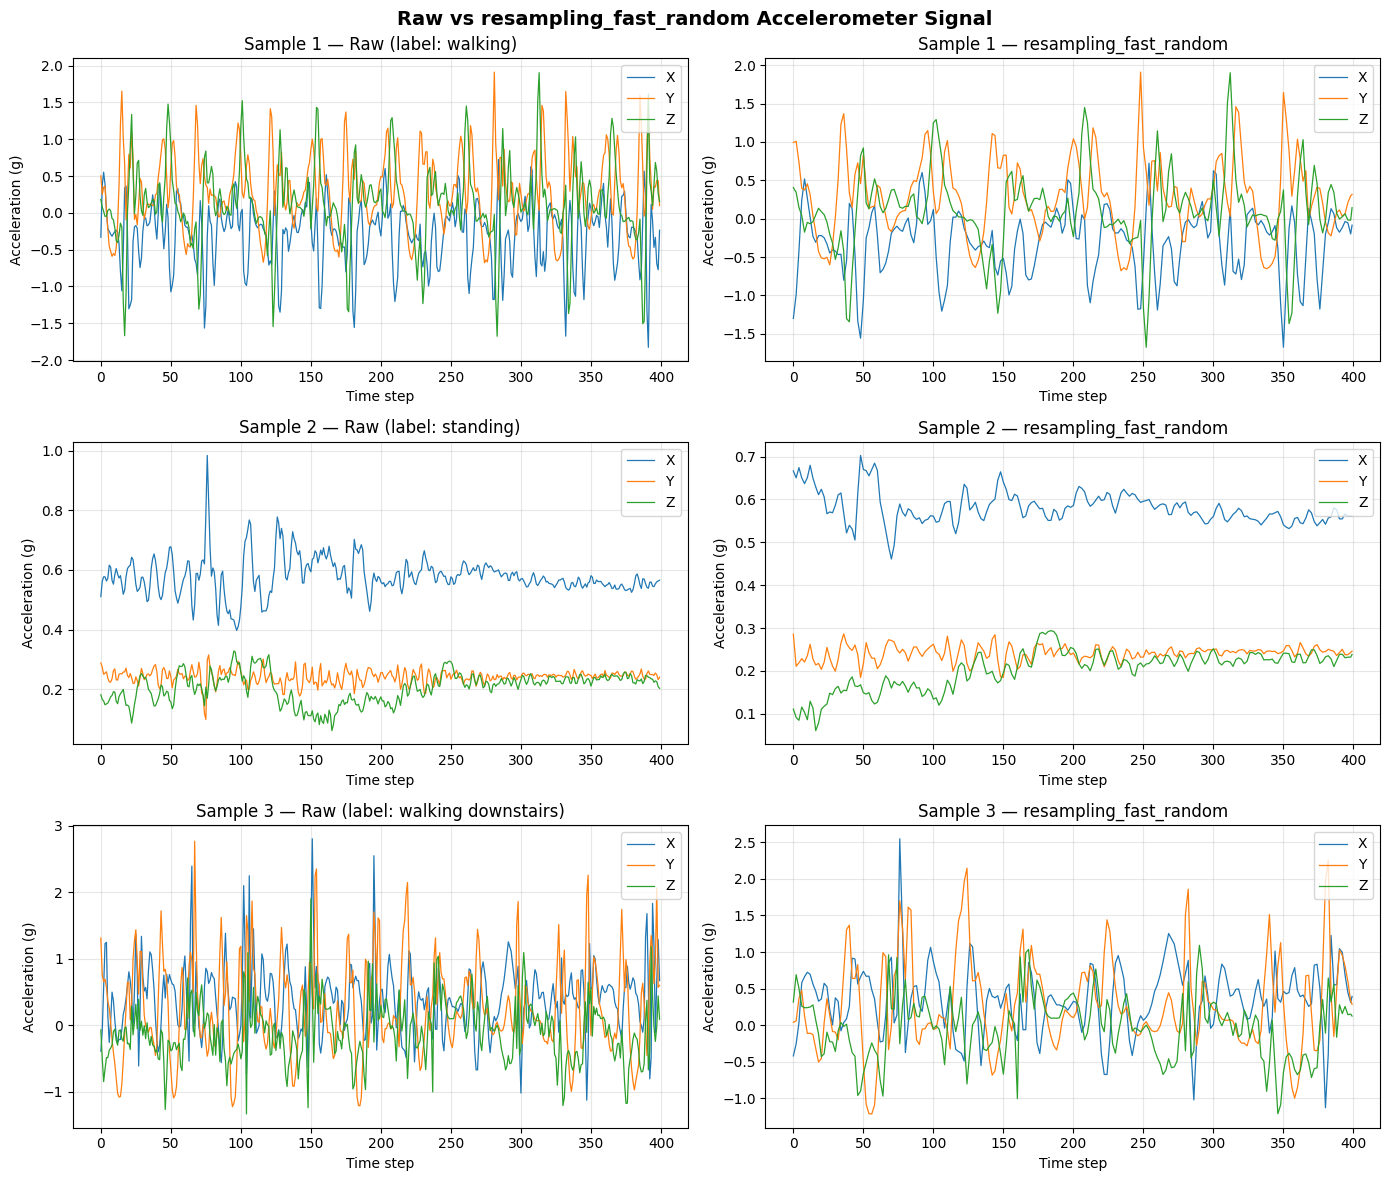

In [15]:
plot_raw_vs_transformed(np_train, n_samples=3, transform=transformations.resampling_fast_random)

In [5]:
def plot_raw_vs_transformed_freq(np_train, n_samples=3, transform='rotation',
                                  label_names=None, sampling_rate=50.0):
    """
    Plot raw vs transformed accelerometer signals side by side in the frequency domain.

    Args:
        np_train:       tuple of (X, y) where X has shape (N, window_size, 3)
        n_samples:      number of example windows to plot
        transform:      callable transformation to apply to the windows
        label_names:    list mapping class index -> full label name.
                        Defaults to label_list_full_name if None.
        sampling_rate:  sampling frequency in Hz (default: 50.0 Hz)
    """
    if callable(transform):
        transform_fn   = transform
        transform_name = transform.__name__
    else:
        raise TypeError(f"`transform` must be a callable, got {type(transform)}.")

    if label_names is None:
        label_names = label_list_full_name

    X, y = np_train[0], np_train[1]
    sample_windows      = X[:n_samples]
    transformed_windows = transform_fn(sample_windows)

    axes_labels = ['X', 'Y', 'Z']
    axes_colors = ['tab:blue', 'tab:orange', 'tab:green']

    window_size = sample_windows.shape[1]
    freqs       = rfftfreq(window_size, d=1.0 / sampling_rate)  # frequency bins in Hz

    fig, axes = plt.subplots(n_samples, 2, figsize=(14, 4 * n_samples))
    if n_samples == 1:
        axes = axes[np.newaxis, :]  # ensure 2D indexing works for a single sample
    fig.suptitle(f'Raw vs {transform_name} — Frequency Domain',
                 fontsize=14, fontweight='bold')

    for i in range(n_samples):
        raw         = sample_windows[i]       # (window_size, 3)
        transformed = transformed_windows[i]  # (window_size, 3)

        ax_raw  = axes[i, 0]
        ax_tran = axes[i, 1]

        for j, (label, color) in enumerate(zip(axes_labels, axes_colors)):
            raw_mag  = np.abs(rfft(raw[:, j]))         # magnitude spectrum
            tran_mag = np.abs(rfft(transformed[:, j]))

            ax_raw.plot(freqs,  raw_mag,  label=label, color=color, linewidth=0.9)
            ax_tran.plot(freqs, tran_mag, label=label, color=color, linewidth=0.9)

        class_idx  = y[i].argmax()
        class_name = label_names[class_idx] if class_idx < len(label_names) else class_idx

        ax_raw.set_title(f'Sample {i+1} — Raw (label: {class_name})')
        ax_tran.set_title(f'Sample {i+1} — {transform_name}')

        for ax in (ax_raw, ax_tran):
            ax.set_xlabel('Frequency (Hz)')
            ax.set_ylabel('Magnitude')
            ax.legend(loc='upper right')
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

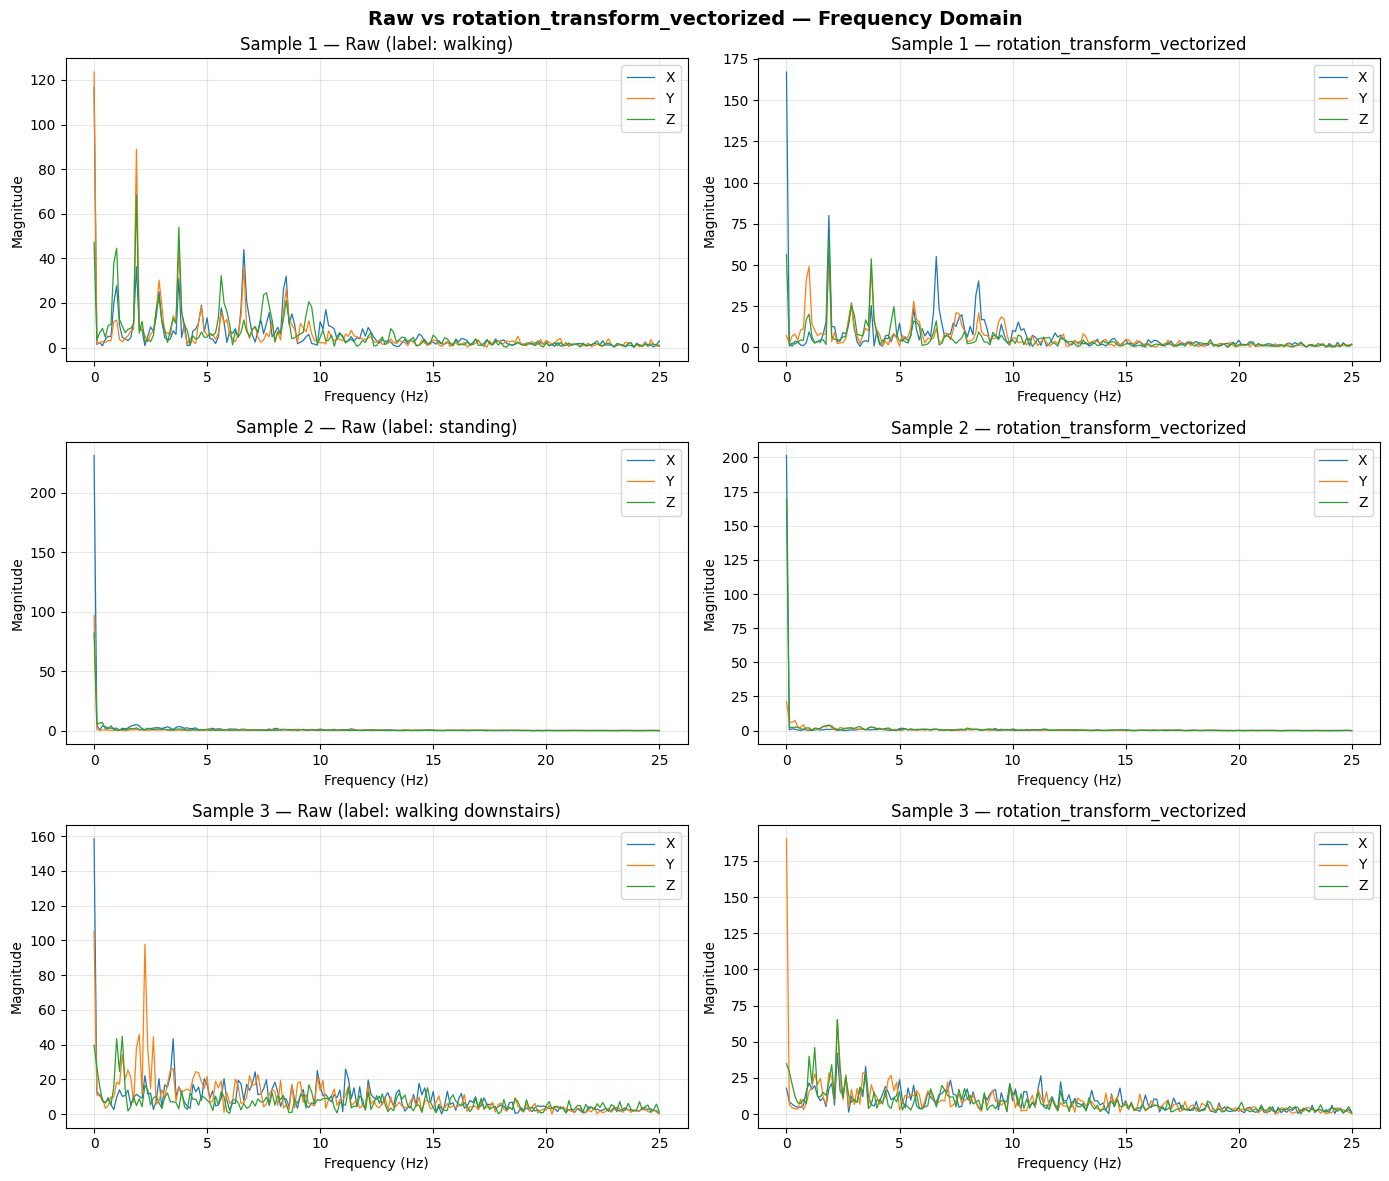

In [6]:
plot_raw_vs_transformed_freq(np_train, n_samples=3, transform=transformations.rotation_transform_vectorized)

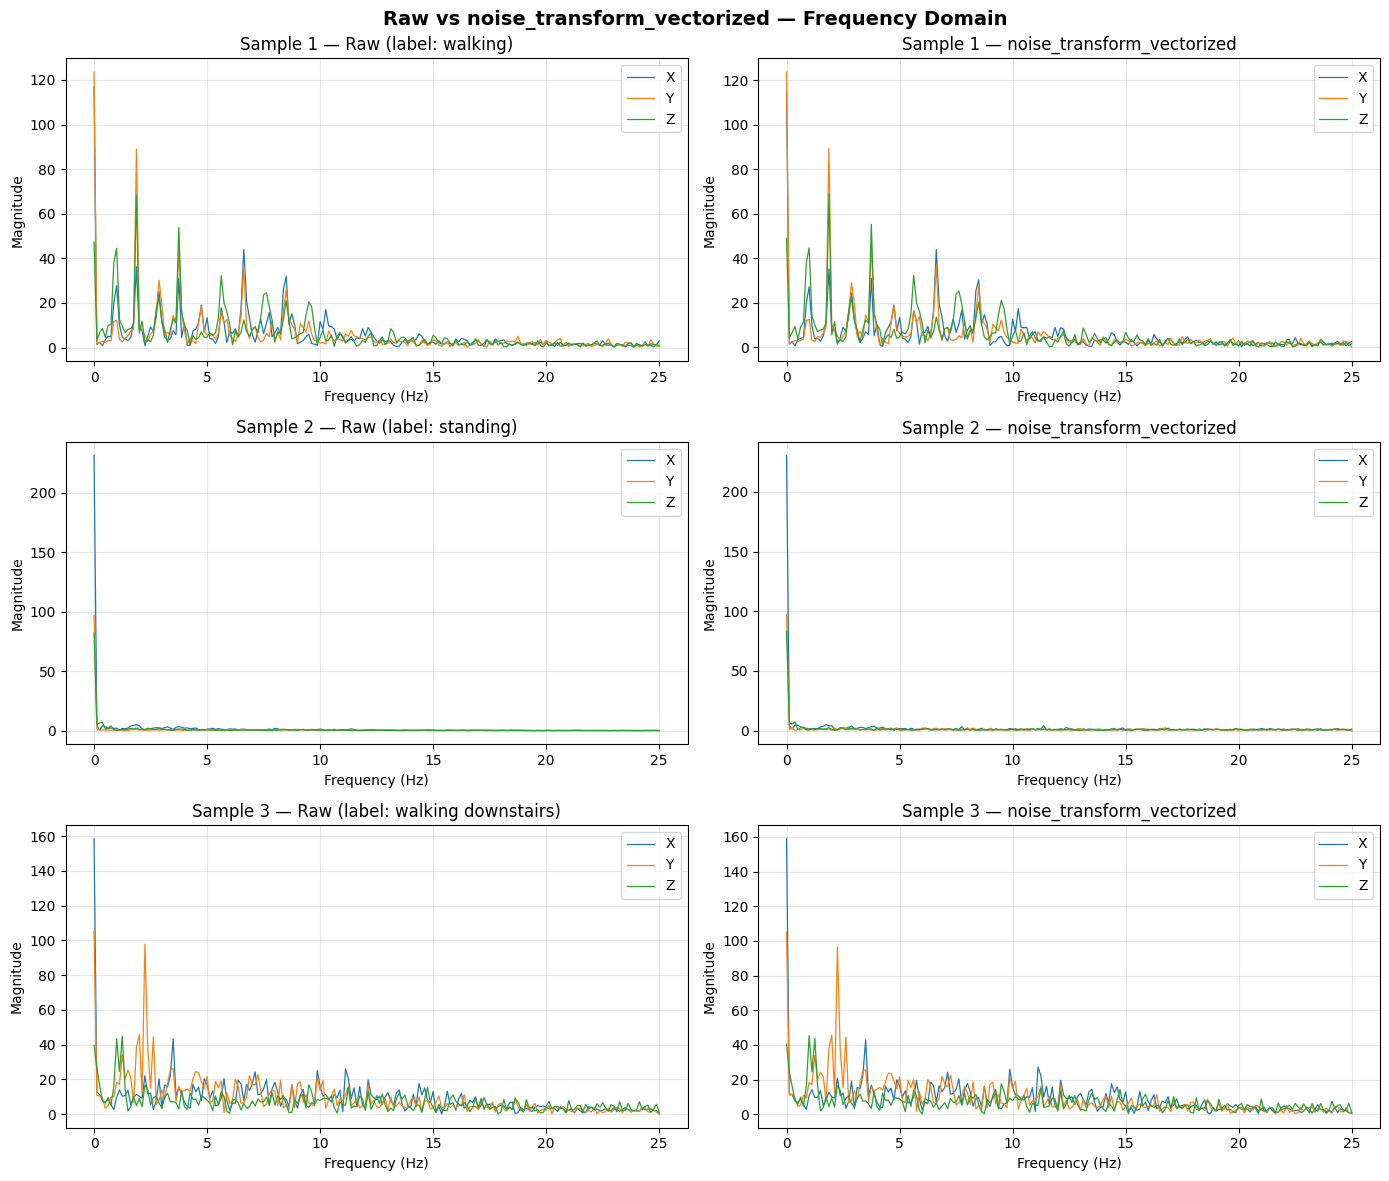

In [7]:
plot_raw_vs_transformed_freq(np_train, n_samples=3, transform=transformations.noise_transform_vectorized)

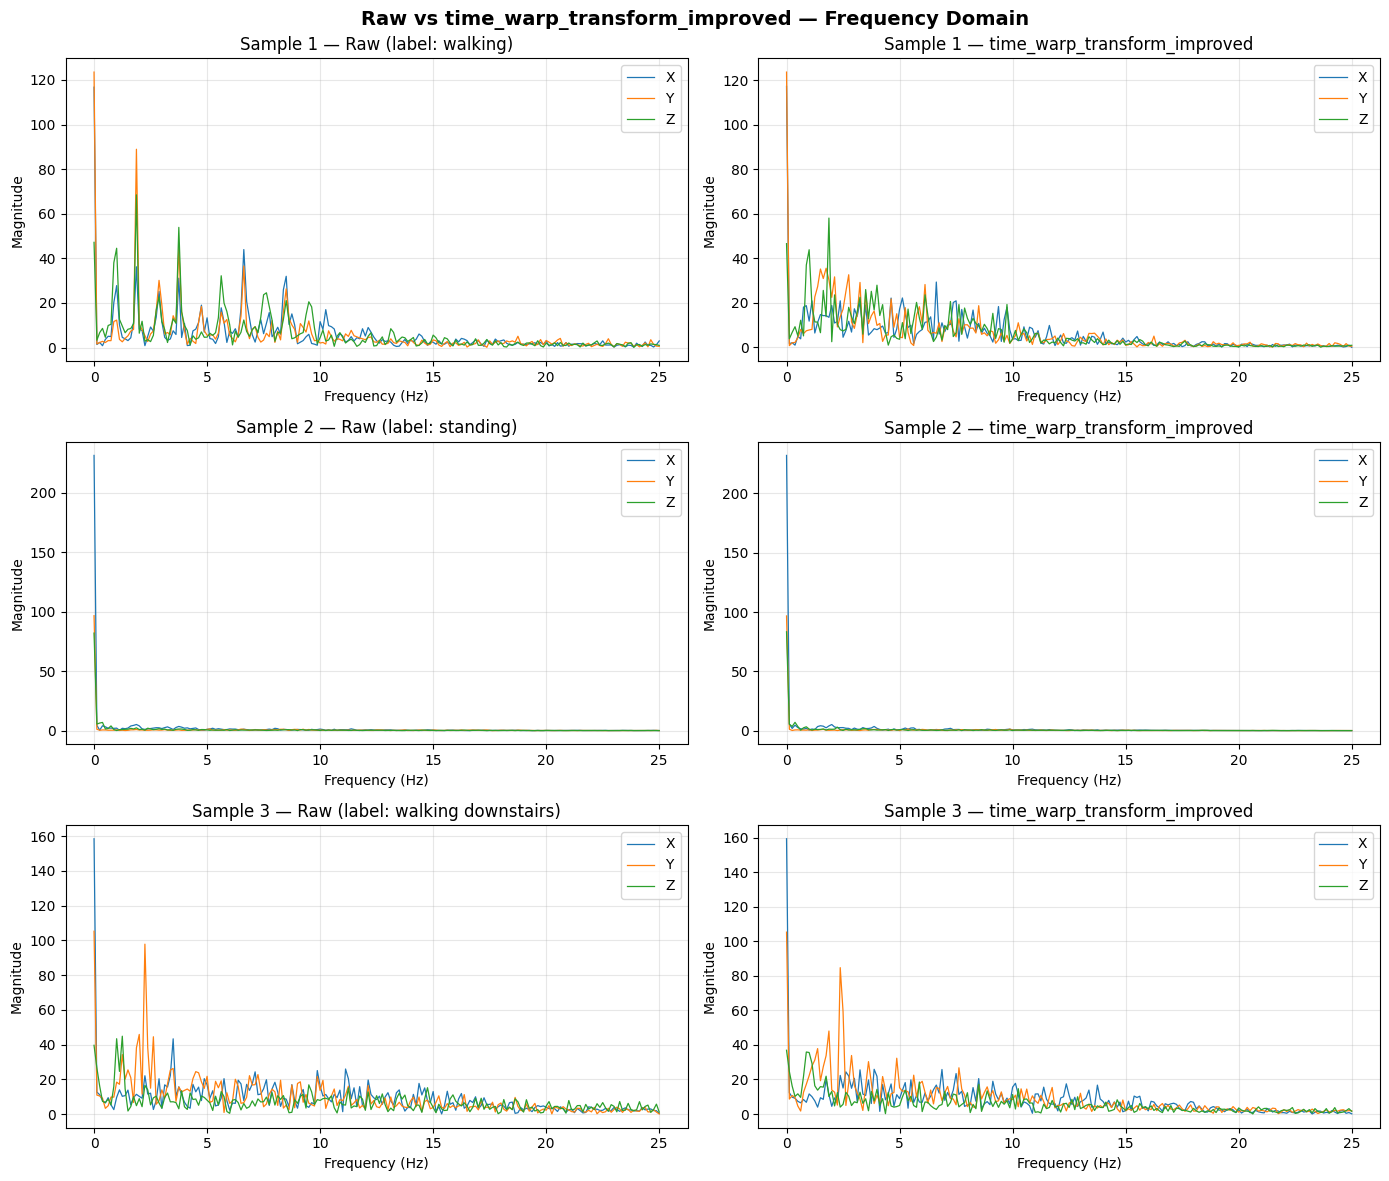

In [8]:
plot_raw_vs_transformed_freq(np_train, n_samples=3, transform=transformations.time_warp_transform_improved)

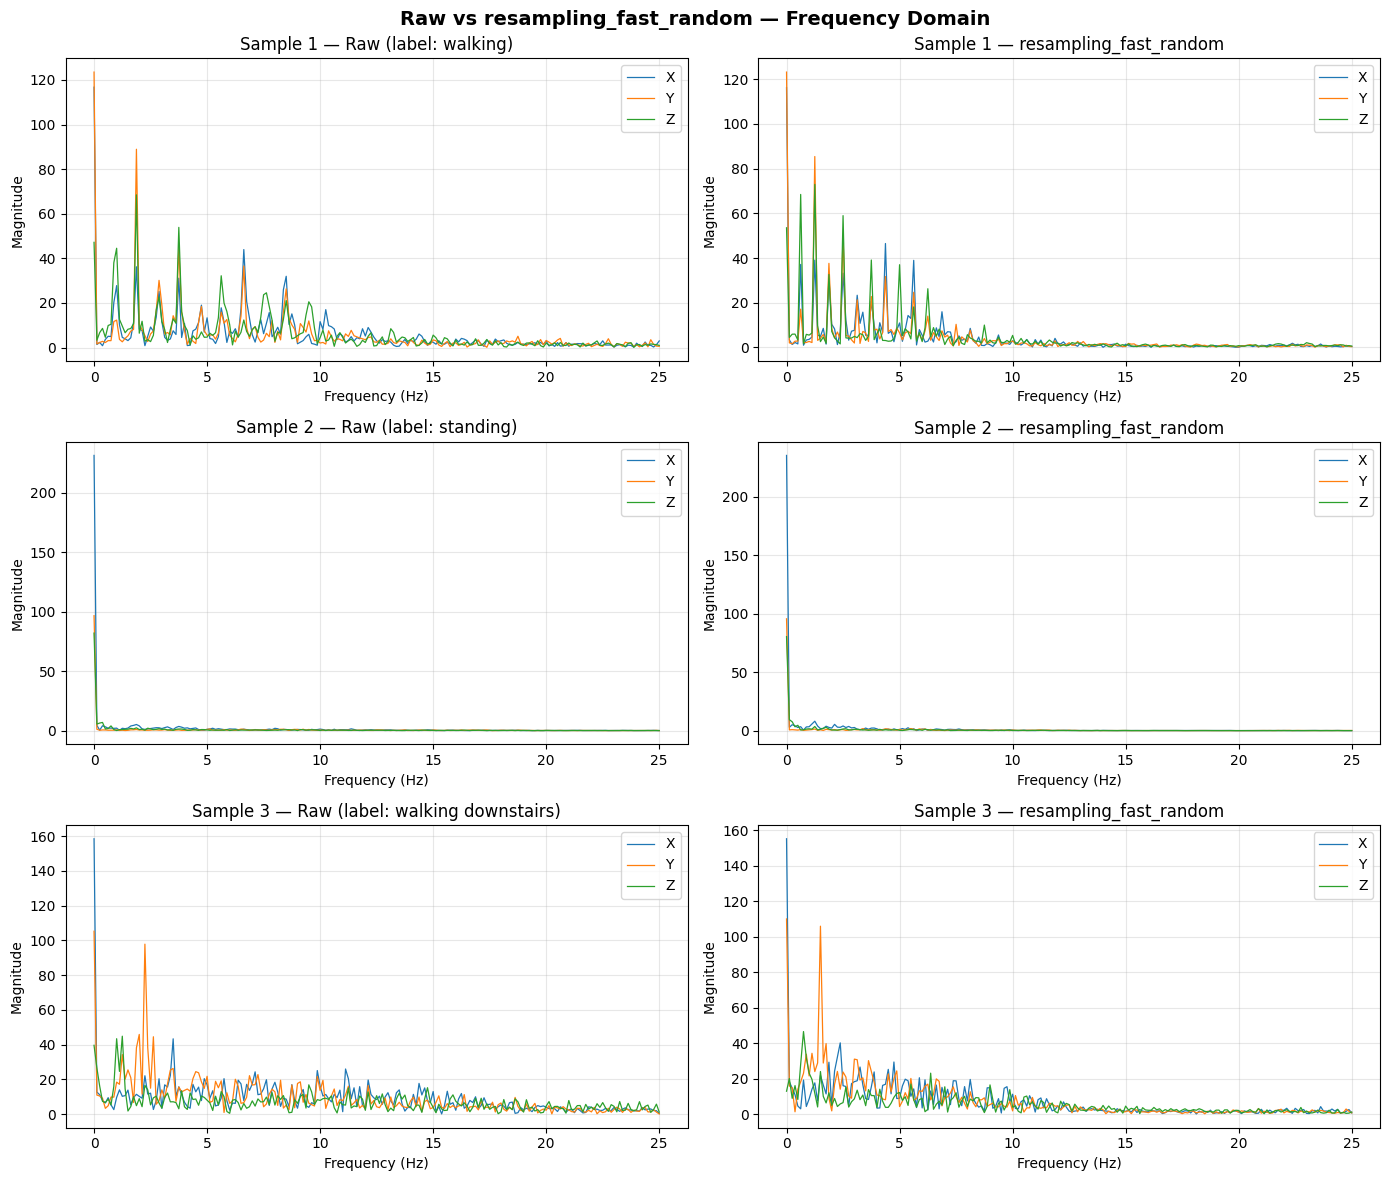

In [9]:
plot_raw_vs_transformed_freq(np_train, n_samples=3, transform=transformations.resampling_fast_random)